In [4]:

                          
T_folder = '/mnt/d/lding/DSI/promega/processing/Batch 1/Treshold'


M_folder = '/mnt/d/lding/DSI/promega/processing/Batch 1/Manuais'


In [5]:
import os
import shutil
new_seg_folder = '/mnt/d/lding/DSI/promega/processing/Batch 1/Dy30_seg'

os.makedirs(new_seg_folder,exist_ok=True)
original_image_folder ='/mnt/d/lding/DSI/promega/promega/Dy30'
training_image_folder = '/mnt/d/lding/DSI/promega/processing/Batch 1/Dy30_image'
os.makedirs(training_image_folder,exist_ok=True)

for n in range(1,13):
    for letterid in range(0,9):
        position_str = chr(65 + letterid)+str(n)
        if os.path.isfile(os.path.join(T_folder,'Mask_T Ba1 96_1 Dy30 '+position_str+' Z2.tif')):
            shutil.copyfile(os.path.join(T_folder,'Mask_T Ba1 96_1 Dy30 '+position_str+' Z2.tif'),
                            os.path.join(new_seg_folder,'Mask Ba1 96_1 Dy30 '+position_str+' Z2.tif'))
            shutil.copyfile(os.path.join(original_image_folder,'Ba1 96_1 Dy30 '+position_str+' Z2.tif'),
                            os.path.join(training_image_folder,'Image Ba1 96_1 Dy30 '+position_str+' Z2.tif'))
        else:
            if os.path.isfile(os.path.join(M_folder,'Mask_M Ba1 96_1 Dy30 '+position_str+' Z2.tif')):
                shutil.copyfile(os.path.join(M_folder,'Mask_M Ba1 96_1 Dy30 '+position_str+' Z2.tif'),
                                os.path.join(new_seg_folder,'Mask Ba1 96_1 Dy30 '+position_str+' Z2.tif'))
                shutil.copyfile(os.path.join(original_image_folder,'Ba1 96_1 Dy30 '+position_str+' Z2.tif'),
                            os.path.join(training_image_folder,'Image Ba1 96_1 Dy30 '+position_str+' Z2.tif'))
            


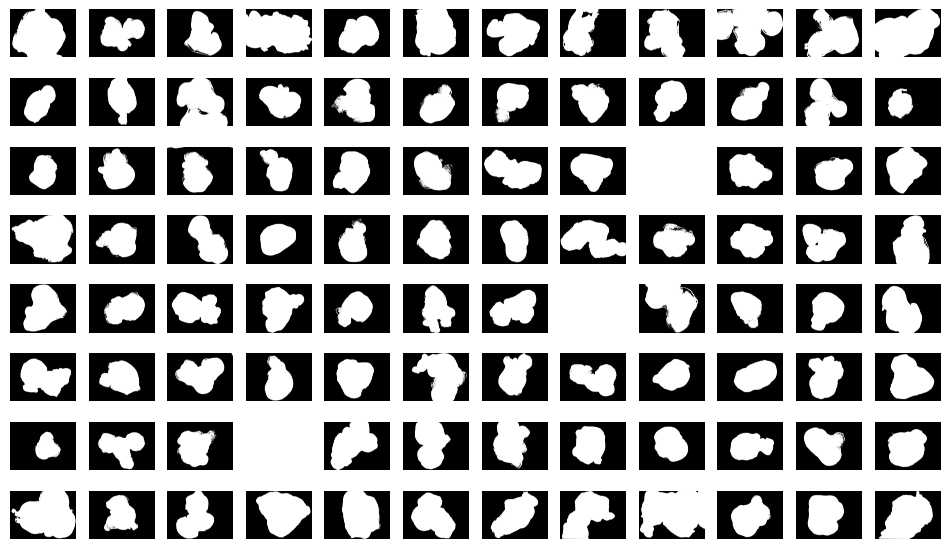

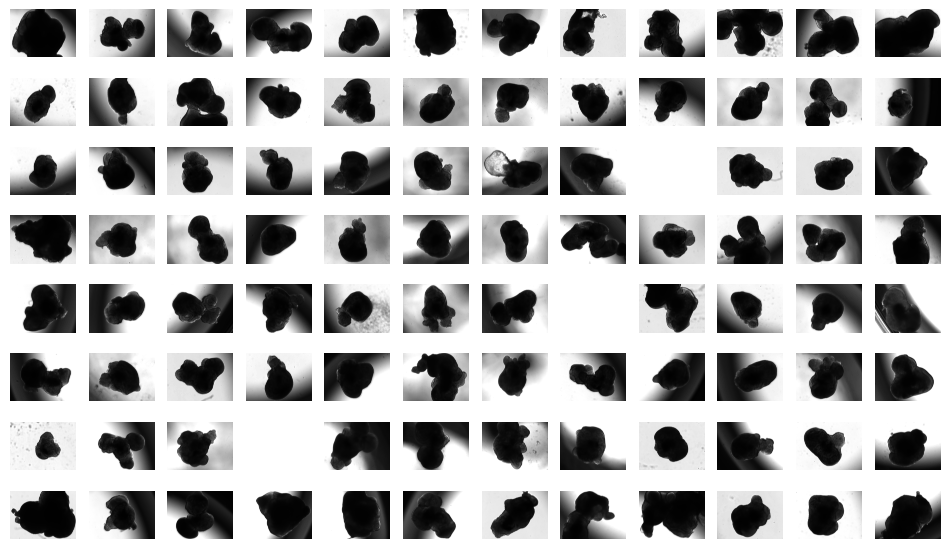

In [6]:
import matplotlib.pyplot as plt
import tifffile
fig, ax = plt.subplots(8, 12, figsize=(12, 7))

for n in range(1,13):
    for letterid in range(0,8):
        position_str = chr(65 + letterid)+str(n)
        ax[letterid,n-1].axis('off')       
        if os.path.isfile(os.path.join(new_seg_folder,'Mask Ba1 96_1 Dy30 '+position_str+' Z2.tif')):
            mask = tifffile.imread(os.path.join(new_seg_folder,'Mask Ba1 96_1 Dy30 '+position_str+' Z2.tif'))
            ax[letterid,n-1].imshow(mask,cmap='gray')



fig, ax = plt.subplots(8, 12, figsize=(12, 7))

for n in range(1,13):
    for letterid in range(0,8):
        position_str = chr(65 + letterid)+str(n)
        ax[letterid,n-1].axis('off')       
        if os.path.isfile(os.path.join(training_image_folder,'Image Ba1 96_1 Dy30 '+position_str+' Z2.tif')):
            mask = tifffile.imread(os.path.join(training_image_folder,'Image Ba1 96_1 Dy30 '+position_str+' Z2.tif'))
            ax[letterid,n-1].imshow(mask,cmap='gray')
            

In [7]:
import matplotlib.cm as cm
import numpy as np

# build the colormap with iterative tab10
tab10 = cm.get_cmap('tab10', 10)
for i in range(10):
    tab10.colors = np.concatenate([tab10.colors,tab10.colors],axis=0)    
tab10.colors = np.concatenate([np.zeros([1,4]),tab10.colors],axis=0)

newmap = cm.get_cmap('tab10', 4000+1)
newmap.colors = tab10.colors[0:4000+1,:]
newmap.colors[0,:]  = np.zeros([1,4])
newmap.colors[0,3] = 1

/tmp/ipykernel_2631321/1212927731.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  tab10 = cm.get_cmap('tab10', 10)
/tmp/ipykernel_2631321/1212927731.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  newmap = cm.get_cmap('tab10', 4000+1)


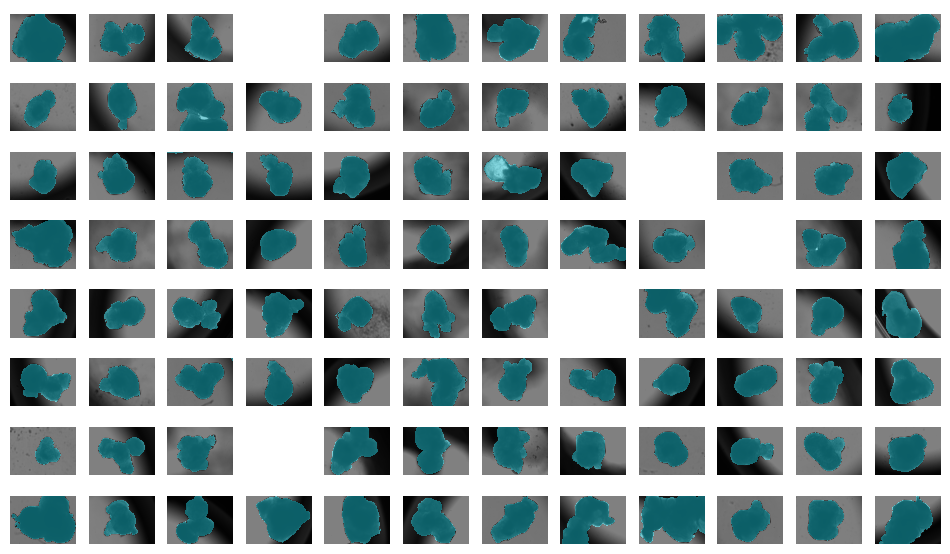

In [8]:
import scipy.ndimage as ndi
from skimage.morphology import remove_small_objects, binary_opening, binary_closing, binary_dilation, disk

fig, ax = plt.subplots(8, 12, figsize=(12, 7))

for n in range(1,13):
    for letterid in range(0,8):
        position_str = chr(65 + letterid)+str(n)
        ax[letterid,n-1].axis('off')       
        if os.path.isfile(os.path.join(training_image_folder,'Image Ba1 96_1 Dy30 '+position_str+' Z2.tif')):
            image = tifffile.imread(os.path.join(training_image_folder,'Image Ba1 96_1 Dy30 '+position_str+' Z2.tif'))
            mask = tifffile.imread(os.path.join(new_seg_folder,'Mask Ba1 96_1 Dy30 '+position_str+' Z2.tif'))
            mask = ndi.binary_fill_holes(mask)
            mask = binary_closing(mask, disk(5))
            ax[letterid,n-1].imshow(image,cmap='gray')
            ax[letterid,n-1].imshow(mask,cmap=newmap, alpha=0.5, interpolation='none')
        

In [1]:
import scipy.ndimage as ndi
from skimage.morphology import remove_small_objects, binary_opening, binary_closing, binary_dilation, disk

fig, ax = plt.subplots(8, 12, figsize=(12, 7))

for n in range(1,13):
    for letterid in range(0,8):
        position_str = chr(65 + letterid)+str(n)
        ax[letterid,n-1].axis('off')       
        if os.path.isfile(os.path.join(training_image_folder,'Image Ba1 96_1 Dy30 '+position_str+' Z2.tif')):
            image = tifffile.imread(os.path.join(training_image_folder,'Image Ba1 96_1 Dy30 '+position_str+' Z2.tif'))
            mask = tifffile.imread(os.path.join(new_seg_folder,'Mask Ba1 96_1 Dy30 '+position_str+' Z2.tif'))
            mask = ndi.binary_fill_holes(mask)
            mask = binary_closing(mask, disk(5))
            ax[letterid,n-1].imshow(image,cmap='gray')
            ax[letterid,n-1].imshow(mask,cmap=newmap, alpha=0.5, interpolation='none')
        

NameError: name 'plt' is not defined

In [ ]:
D:\lding\DSI\promega\promega\Dy30